In [1]:
!pip install trl bitsandbytes -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00


In [2]:
from huggingface_hub import hf_hub_download
from datasets import Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import TrainerCallback, TrainerControl, TrainerState
from peft import LoraConfig, get_peft_model
from trl import DPOTrainer, DPOConfig
from tqdm.auto import tqdm

In [3]:
train_path = hf_hub_download(
    repo_id="Psychotherapy-LLM/PsychoCounsel-Preference",
    repo_type="dataset",
    filename="data/train-00000-of-00001.parquet"
)

test_path = hf_hub_download(
    repo_id="Psychotherapy-LLM/PsychoCounsel-Preference",
    repo_type="dataset",
    filename="data/test-00000-of-00001.parquet"
)

print(train_path)
print(test_path)

data/train-00000-of-00001.parquet:   0%|          | 0.00/37.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/3.81M [00:00<?, ?B/s]

/root/.cache/huggingface/hub/datasets--Psychotherapy-LLM--PsychoCounsel-Preference/snapshots/e6b885f3f99f93dd21b8c00d171c3fe9740bb615/data/train-00000-of-00001.parquet
/root/.cache/huggingface/hub/datasets--Psychotherapy-LLM--PsychoCounsel-Preference/snapshots/e6b885f3f99f93dd21b8c00d171c3fe9740bb615/data/test-00000-of-00001.parquet


In [4]:
train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

In [5]:
train.columns

Index(['ID', 'prefID', 'question', 'chosen', 'rejected', 'chosen_model',
       'rejected_model', 'chosen_empathy_rating', 'chosen_relevance_rating',
       'chosen_clarity_rating', 'chosen_safety_rating',
       'chosen_exploration_rating', 'chosen_autonomy_rating',
       'chosen_staging_rating', 'rejected_empathy_rating',
       'rejected_relevance_rating', 'rejected_clarity_rating',
       'rejected_safety_rating', 'rejected_exploration_rating',
       'rejected_autonomy_rating', 'rejected_staging_rating'],
      dtype='object')

In [6]:
len(train)

34329

In [7]:
train.head(5)

,ID,prefID,question,chosen,rejected,chosen_model,rejected_model,chosen_empathy_rating,chosen_relevance_rating,chosen_clarity_rating,...,chosen_exploration_rating,chosen_autonomy_rating,chosen_staging_rating,rejected_empathy_rating,rejected_relevance_rating,rejected_clarity_rating,rejected_safety_rating,rejected_exploration_rating,rejected_autonomy_rating,rejected_staging_rating
0,therapistQA-4356,0,Please help. I really don’t like my boyfriend...,Thank you for sharing your feelings so openly....,It sounds like you have developed some mixed f...,GPT-4o-mini,MiniCPM3-4B,5,5,4,...,4,4,4,3,4,3,4,5,2,3
1,mentalChat16k-1726,1,I've always felt like I've failed as a mother ...,I hear you sharing your deep concerns and fee...,It sounds like you're experiencing a lot of gu...,Phi-3.5-mini-instruct,MiniCPM3-4B,5,5,2,...,4,5,4,4,3,4,4,2,2,3
2,mentalChat16k-1726,2,I've always felt like I've failed as a mother ...,Thank you for sharing that with me. It sounds ...,It sounds like you're experiencing a lot of gu...,Qwen2.5-7B-Instruct,MiniCPM3-4B,4,4,3,...,5,4,4,4,3,4,4,2,2,3
3,psycho8k-3135,3,I've been struggling with maintaining good gra...,I'm really sorry to hear that you're feeling c...,I'm sorry to hear that you've been struggling ...,Ministral-8B-Instruct-2410,deepseek-llm-67b-chat,4,5,2,...,5,5,4,3,3,3,4,3,4,3
4,psycho8k-5118,4,I'm struggling with my son's transition from s...,I can sense the concern and worry in your voic...,It sounds like your son is experiencing a sign...,Llama-3.2-3B-Instruct,MiniCPM3-4B,5,5,3,...,4,5,4,3,3,4,5,2,4,3


In [8]:
# train = train.sample(1000)
# test = test.sample(100)

In [9]:
weights = {
    "exploration": 0.22, 
    "staging":     0.18, 
    "autonomy":    0.15,  
    "empathy":     0.22,  
    "relevance":   0.15, 
    "safety":      0.05, 
    "clarity":     0.03                    
}

def calculate_score(row, prefix):
    score = (
        row[f"{prefix}_empathy_rating"] * weights["empathy"] +
        row[f"{prefix}_relevance_rating"] * weights["relevance"] +
        row[f"{prefix}_clarity_rating"] * weights["clarity"] +
        row[f"{prefix}_safety_rating"] * weights["safety"] +
        row[f"{prefix}_exploration_rating"] * weights["exploration"] +
        row[f"{prefix}_autonomy_rating"] * weights["autonomy"] +
        row[f"{prefix}_staging_rating"] * weights["staging"]
    )
    return score

train['chosen_score'] = train.apply(lambda x: calculate_score(x, 'chosen'), axis=1)
train['rejected_score'] = train.apply(lambda x: calculate_score(x, 'rejected'), axis=1)
train['margin'] = train['chosen_score'] - train['rejected_score']

test['chosen_score'] = test.apply(lambda x: calculate_score(x, 'chosen'), axis=1)
test['rejected_score'] = test.apply(lambda x: calculate_score(x, 'rejected'), axis=1)
test['margin'] = test['chosen_score'] - test['rejected_score']

In [10]:
rating_types = ['empathy','safety','autonomy','relevance','clarity','staging','exploration']
chosen_cols = [f'chosen_{r}_rating' for r in rating_types]
rejected_cols = [f'rejected_{r}_rating' for r in rating_types]
chosen_means = train[chosen_cols].mean()
rejected_means = train[rejected_cols].mean()
chosen_score_mean = train['chosen_score'].mean()
rejected_score_mean = train['rejected_score'].mean()
chosen_means.index = rating_types
rejected_means.index = rating_types
margins = chosen_means - rejected_means
margins_sorted = margins.sort_values(ascending=False)

In [11]:
sorted_metrics = margins.sort_values(ascending=False).index
labels = list(sorted_metrics) + ['overall_score']
chosen_vals = list(chosen_means[sorted_metrics].values) + [chosen_score_mean]
rejected_vals = list(rejected_means[sorted_metrics].values) + [rejected_score_mean]

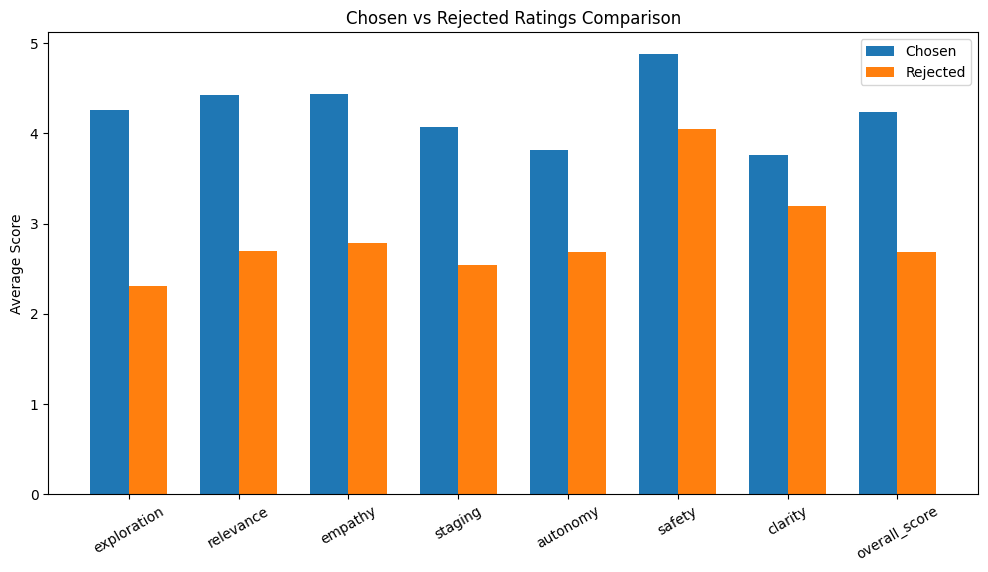

In [12]:
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(12,6))
plt.bar(x - width/2, chosen_vals, width, label='Chosen')
plt.bar(x + width/2, rejected_vals, width, label='Rejected')
plt.xticks(x, labels, rotation=30)
plt.ylabel("Average Score")
plt.title("Chosen vs Rejected Ratings Comparison")
plt.legend();

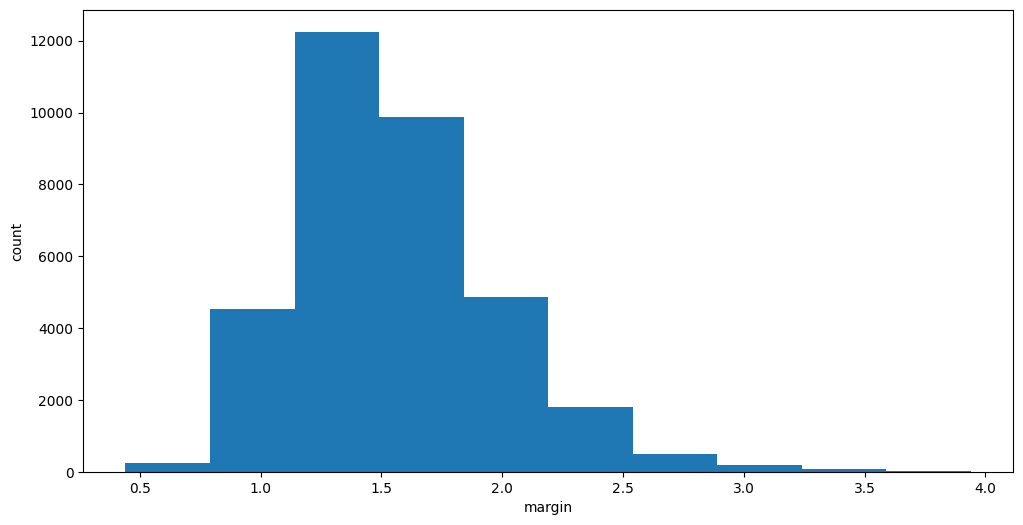

In [13]:
plt.figure(figsize=(12,6))
plt.hist(train['margin'])
plt.xlabel('margin')
plt.ylabel('count');

In [14]:
train = train[train['margin'] >= 1].copy()
test  = test[test['margin']   >= 1].copy()
print(f"Remaining: {len(train)}")

Remaining: 32622


In [15]:
train['margin'] = train['margin']/train['margin'].mean()
test['margin'] = test['margin']/test['margin'].mean()

In [16]:
model_path = '/kaggle/input/models/pytorch2k25/sft-model/pytorch/default/1/final_merged_model/'
tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.padding_side = "left"  
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.config.use_cache = False

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [17]:
tokenizer.special_tokens_map

{'bos_token': '<|im_start|>',
 'eos_token': '<|im_end|>',
 'unk_token': '<|endoftext|>',
 'pad_token': '<|im_end|>'}

In [18]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    use_dora=True
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 5,040,000 || all params: 139,555,008 || trainable%: 3.6115


In [19]:
SYSTEM = "You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses."

def format_dpo(row, tokenizer):
    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": str(row["question"]).lower().strip()},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    return {
        "prompt":   prompt,
        "chosen":   str(row["chosen"]),
        "rejected": str(row["rejected"]),
    }

In [20]:
trainset = Dataset.from_list([format_dpo(row, tokenizer) for _, row in train.iterrows()])
testset  = Dataset.from_list([format_dpo(row, tokenizer) for _, row in test.iterrows()])

In [21]:
print(trainset[0]['prompt'])

<|im_start|>system
You are a compassionate AI mental health assistant. Respond with empathy, provide supportive guidance, and encourage healthy coping strategies without giving medical diagnoses.<|im_end|>
<|im_start|>user
i've always felt like i've failed as a mother because i couldn't provide my son with a normal childhood, filled with consistent routines and activities. my middle sister's health issues have made it difficult for us to engage in traditional family activities, and i've felt like i've let my son down as a result.<|im_end|>
<|im_start|>assistant



In [22]:
print(trainset[0]['chosen'])

 I hear you sharing your deep concerns and feelings of guilt about your situation. It's important to remember that being a parent isn't about providing a perfect or 'normal' childhood. Every family faces challenges, and it's how we navigate them that truly matters.

The struggles you're dealing with due to your sister's health issues are indeed significant, and they've impacted your ability to participate in traditional activities. However, creating a nurturing environment for your son doesn't necessarily mean adhering strictly to societal norms. You are making the best of a difficult situation, and that already speaks volumes about your love and dedication as a parent.

Here are a few thoughts to consider:

1. **Recognize your efforts**: You're doing more than you may realize. You're managing your sister's health issues while trying to raise your son. That's no small feat, and it takes a lot of strength and courage.

2. **Adapt and improvise**: Life doesn't always go as planned, and t

In [23]:
print(trainset[0]['rejected'])

It sounds like you're experiencing a lot of guilt and self-doubt as a mother, which can be an incredibly challenging emotion to navigate. However, it's important to remember that parenting is not about creating a perfect environment, but rather about providing what you can given your circumstances. Your son's health and well-being should be your top priority, and finding ways to connect with him and provide love and support is what truly matters. It may also be helpful to consider seeking support from a therapist or support group to work through these feelings and develop coping strategies.


  0%|          | 0/32622 [00:00<?, ?it/s]


--- Token Length Statistics ---
Chosen   | Max: 1953 | Mean: 424.4 | 99th Pct: 910
Rejected | Max: 3982 | Mean: 357.2 | 99th Pct: 800


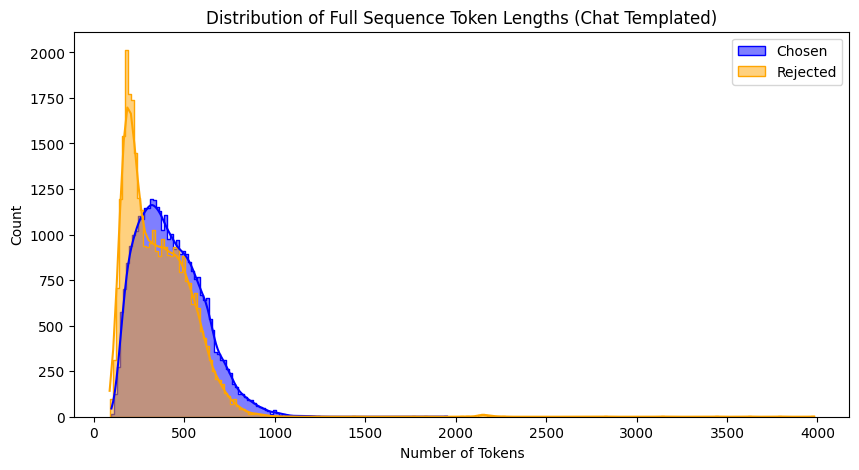

In [24]:
def get_token_lengths(df, tokenizer):
    chosen_lens = []
    rejected_lens = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        chosen_messages = [
            {"role": "system","content": SYSTEM},
            {"role": "user","content": str(row["question"]).lower().strip()},
            {"role": "assistant","content": str(row["chosen"])}
        ]
        rejected_messages = [
            {"role": "system","content": SYSTEM},
            {"role": "user","content": str(row["question"]).lower().strip()},
            {"role": "assistant","content": str(row["rejected"])}
        ]
        
        c_text = tokenizer.apply_chat_template(chosen_messages,   tokenize=False, add_generation_prompt=False)
        r_text = tokenizer.apply_chat_template(rejected_messages, tokenize=False, add_generation_prompt=False)
        
        chosen_lens.append(len(tokenizer.encode(c_text)))
        rejected_lens.append(len(tokenizer.encode(r_text)))
        
    return chosen_lens, rejected_lens


train_chosen_lens, train_rejected_lens = get_token_lengths(train, tokenizer)

print(f"\n--- Token Length Statistics ---")
print(f"Chosen   | Max: {max(train_chosen_lens)} | Mean: {np.mean(train_chosen_lens):.1f} | 99th Pct: {np.percentile(train_chosen_lens, 99):.0f}")
print(f"Rejected | Max: {max(train_rejected_lens)} | Mean: {np.mean(train_rejected_lens):.1f} | 99th Pct: {np.percentile(train_rejected_lens, 99):.0f}")

plt.figure(figsize=(10, 5))
sns.histplot(train_chosen_lens,color="blue",label="Chosen",kde=True,element="step")
sns.histplot(train_rejected_lens,color="orange",label="Rejected",kde=True,element="step")
plt.title("Distribution of Full Sequence Token Lengths (Chat Templated)")
plt.xlabel("Number of Tokens")
plt.legend();

In [25]:
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f"Memory cleared. Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

clear_memory()

Memory cleared. Allocated: 143.47 MB


In [26]:
num_epochs = 2
batch_size = 4
grad_accum_steps = 4
effective_batch_size = batch_size * grad_accum_steps
total_train_steps = (len(trainset) // effective_batch_size) * num_epochs
eval_and_save_steps = max(1, total_train_steps // 4)
warmup_steps = int(0.05 * total_train_steps)
logging_steps = max(1, eval_and_save_steps // 4) 

print(f"Total steps     : {total_train_steps}")
print(f"Eval/save every : {eval_and_save_steps} steps")
print(f"Log every       : {logging_steps} steps")
print(f"Approx log pts  : {total_train_steps // logging_steps}")

Total steps     : 4076
Eval/save every : 1019 steps
Log every       : 254 steps
Approx log pts  : 16


In [27]:
dpo_config = DPOConfig(
    output_dir="./dpo_outputs",
    loss_type=["sigmoid", "sft"],
    loss_weights=[0.85, 0.15],
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=grad_accum_steps,
    num_train_epochs=num_epochs,
    learning_rate=2e-5,         
    lr_scheduler_type="cosine",
    warmup_steps=warmup_steps,
    beta=0.1,                   
    max_length=1024,
    eval_strategy="steps",
    eval_steps=eval_and_save_steps,
    save_strategy="steps",
    save_steps=eval_and_save_steps,
    load_best_model_at_end=True,
    logging_steps=logging_steps,
    fp16=True,
    optim="adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    remove_unused_columns=False,
    report_to="none",
    seed=3407,
)

In [28]:
class EarlyStopOnAccuracy(TrainerCallback):
    def __init__(self, accuracy_threshold=0.8):
        self.accuracy_threshold = accuracy_threshold

    def on_evaluate(self, args, state: TrainerState, control: TrainerControl, metrics=None, **kwargs):
        if metrics is None:
            return control
        
        accuracy = metrics.get("eval_rewards/accuracies")
        if accuracy is None:
            return control

        print(f"\nStep {state.global_step} | Reward Accuracy: {accuracy:.4f}")
        
        if accuracy >= self.accuracy_threshold:
            print(f"Accuracy {accuracy:.4f} >= {self.accuracy_threshold} threshold. Stopping early.")
            control.should_training_stop = True

        return control

In [29]:
class GenerateSamplesCallback(TrainerCallback):
    def __init__(self, tokenizer, testset, num_samples=3, max_new_tokens=200):
        self.tokenizer = tokenizer
        self.num_samples = num_samples
        self.max_new_tokens = max_new_tokens
        self.samples = [testset[i] for i in range(num_samples)]

    def on_evaluate(self, args, state: TrainerState, control: TrainerControl, model=None, **kwargs):
        if model is None:
            return control

        model.eval()
        print(f"\n{'='*60}")
        print(f"  SAMPLE GENERATIONS — Step {state.global_step}")
        print(f"{'='*60}")

        with torch.no_grad():
            for i, sample in enumerate(self.samples):
                prompt = sample["prompt"]
                inputs = self.tokenizer(
                    prompt,
                    return_tensors="pt",
                    truncation=True,
                    max_length=512
                ).to(model.device)

                outputs = model.generate(
                    **inputs,
                    max_new_tokens=self.max_new_tokens,
                    do_sample=False,          
                    pad_token_id=self.tokenizer.eos_token_id,
                )

                generated = outputs[0][inputs["input_ids"].shape[-1]:]
                generated_text = self.tokenizer.decode(generated, skip_special_tokens=True)

                print(f"\n--- Sample {i+1} ---")
                user_line = [l for l in prompt.split("\n") if l.strip()][-1]
                print(f"PROMPT   : {user_line[:120]}...")
                print(f"GENERATED: {generated_text[:300]}")
                print(f"CHOSEN   : {sample['chosen'][:300]}")

        print(f"{'='*60}\n")
        model.train()
        return control

In [30]:
trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_config,
    train_dataset=trainset,
    eval_dataset=testset,
    processing_class=tokenizer,
    callbacks=[
        EarlyStopOnAccuracy(accuracy_threshold=0.8),
        GenerateSamplesCallback(tokenizer, testset, num_samples=2, max_new_tokens=200)
    ]
)

Adding EOS to train dataset:   0%|          | 0/32622 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/32622 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/2202 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2202 [00:00<?, ? examples/s]

In [31]:
print('Starting Training')
trainer.train()

Starting Training


Step,Training Loss,Validation Loss
1019,0.257482,0.292317
2038,0.234292,0.276381
3057,0.227191,0.268999
4076,0.227851,0.270191



  SAMPLE GENERATIONS — Step 1019

--- Sample 1 ---
PROMPT   : <|im_start|>assistant...
GENERATED: Thank you for sharing that with me. It sounds like you’ve been carrying a heavy burden, feeling the weight of your friendships and the impact they’ve had on your life. It’s completely understandable to feel this way when you’re so focused on your relationships that you’ve lost sight of other aspects
CHOSEN   :  I'm really sorry to hear that you're feeling this way. It's understandable that you've found comfort and connection in your friendships, especially given the challenges and isolation we all face. However, it's also important to recognize the value and need for a balanced life where you can nurture 

--- Sample 2 ---
PROMPT   : <|im_start|>assistant...
GENERATED: Thank you for sharing that with me. It sounds like you're experiencing a really challenging time right now, where anxiety is making it hard to make decisions and feel confident in your choices. It’s completely understandabl

TrainOutput(global_step=4078, training_loss=0.2588916894792049, metrics={'train_runtime': 41339.8601, 'train_samples_per_second': 1.578, 'train_steps_per_second': 0.099, 'total_flos': 6.117424982912102e+16, 'train_loss': 0.2588916894792049})

In [32]:
log_history = trainer.state.log_history

steps, chosen, rejected, margins, accuracies = [], [], [], [], []

for log in log_history:
    if "rewards/chosen" in log:
        steps.append(log["step"])
        chosen.append(log["rewards/chosen"])
        rejected.append(log["rewards/rejected"])
        margins.append(log["rewards/margins"])
        accuracies.append(log["rewards/accuracies"])


--- Final Step Reward Summary ---
Chosen Reward  : -1.9532
Rejected Reward: -8.4251
Margin         : 6.4719
Accuracy       : 0.9884


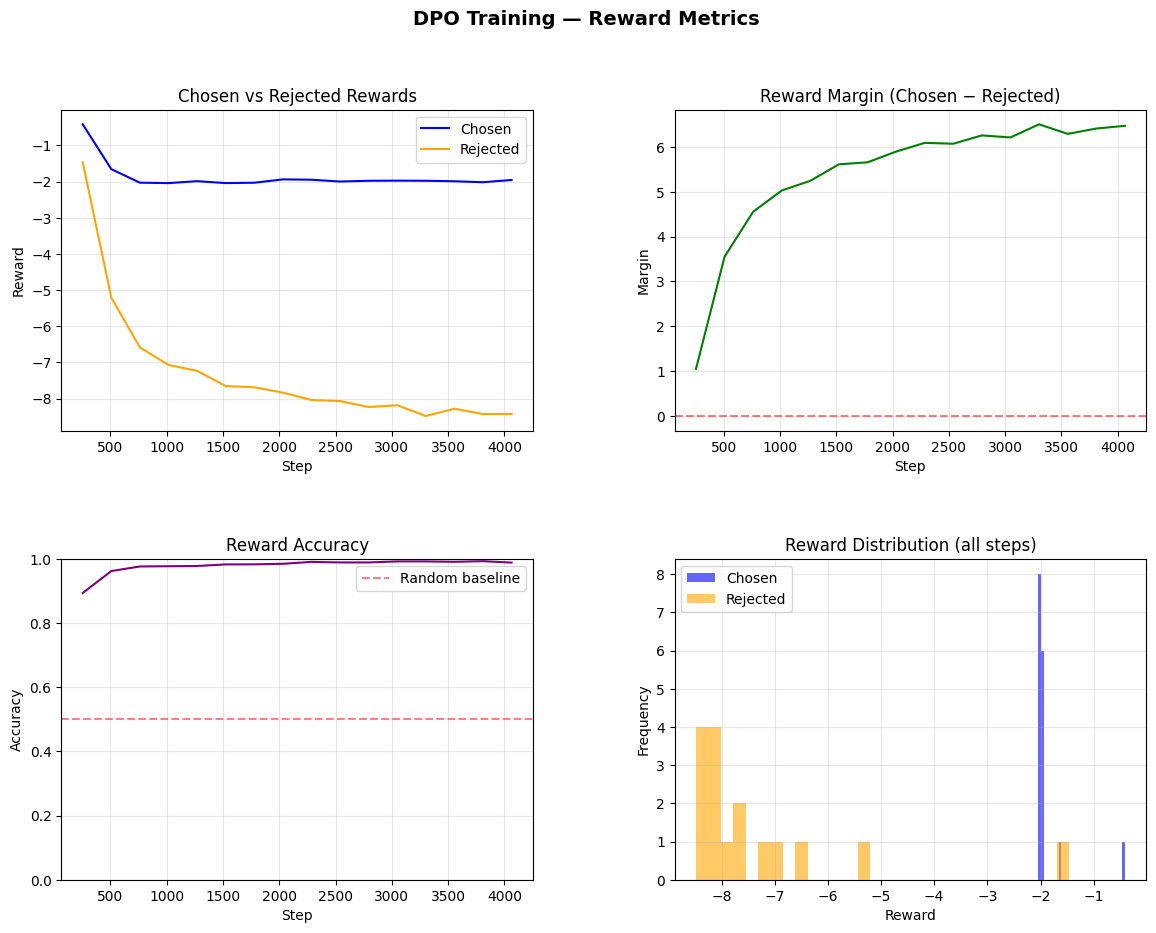

In [33]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(steps, chosen,  label="Chosen",   color="blue")
ax1.plot(steps, rejected, label="Rejected", color="orange")
ax1.set_title("Chosen vs Rejected Rewards")
ax1.set_xlabel("Step")
ax1.set_ylabel("Reward")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(steps, margins, color="green")
ax2.axhline(0, color="red", linestyle="--", alpha=0.5)
ax2.set_title("Reward Margin (Chosen − Rejected)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Margin")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(steps, accuracies, color="purple")
ax3.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Random baseline")
ax3.set_title("Reward Accuracy")
ax3.set_xlabel("Step")
ax3.set_ylabel("Accuracy")
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(chosen,   bins=30, alpha=0.6, color="blue",   label="Chosen")
ax4.hist(rejected, bins=30, alpha=0.6, color="orange", label="Rejected")
ax4.set_title("Reward Distribution (all steps)")
ax4.set_xlabel("Reward")
ax4.set_ylabel("Frequency")
ax4.legend()
ax4.grid(alpha=0.3)

plt.suptitle("DPO Training — Reward Metrics", fontsize=14, fontweight="bold")

print(f"\n--- Final Step Reward Summary ---")
print(f"Chosen Reward  : {chosen[-1]:.4f}")
print(f"Rejected Reward: {rejected[-1]:.4f}")
print(f"Margin         : {margins[-1]:.4f}")
print(f"Accuracy       : {accuracies[-1]:.4f}")

In [34]:
trainer.save_model("./best_dpo_lora")
tokenizer.save_pretrained("./best_dpo_lora")
print("LoRA adapters saved.")

merged_model = model.merge_and_unload()

output_dir = "./final_dpo_model"
merged_model.save_pretrained(output_dir, safe_serialization=True)
tokenizer.save_pretrained(output_dir)
print(f"Merged DPO model saved to: {output_dir}")

del merged_model
gc.collect()
torch.cuda.empty_cache()

LoRA adapters saved.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged DPO model saved to: ./final_dpo_model
